# Methodology Flowcharts
Generates two figures:
- `fig_flowchart_pipeline.png` — overall data pipeline from raw sources to results
- `fig_flowchart_did.png` — DiD identification and estimation design

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from pathlib import Path

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

## Figure 1 — Overall Data Pipeline

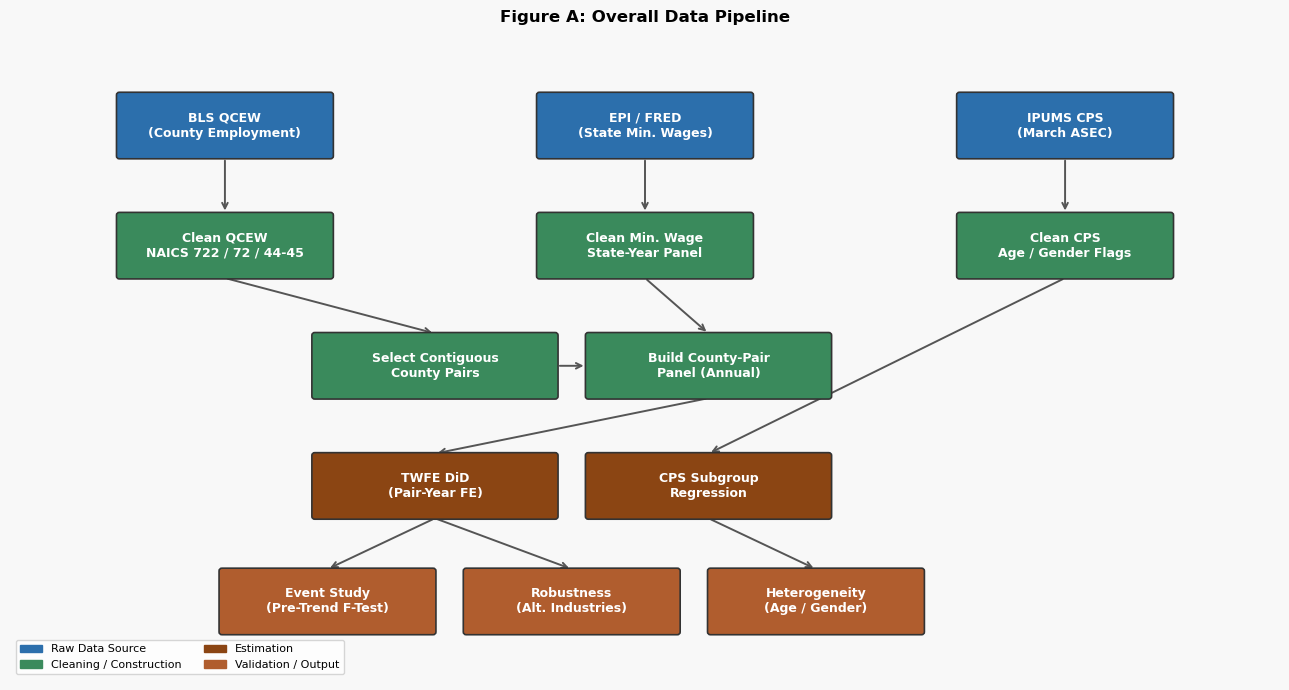

Saved fig_flowchart_pipeline.png


In [2]:
def draw_box(ax, x, y, w, h, text, color, fontsize=9, text_color="white", radius=0.03):
    box = FancyBboxPatch(
        (x - w / 2, y - h / 2),
        w,
        h,
        boxstyle=f"round,pad=0.01,rounding_size={radius}",
        linewidth=1.2,
        edgecolor="#333333",
        facecolor=color,
        zorder=3,
    )
    ax.add_patch(box)
    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        color=text_color,
        fontweight="bold",
        zorder=4,
        wrap=True,
        multialignment="center",
    )


def arrow(ax, x1, y1, x2, y2):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", color="#555555", lw=1.4),
        zorder=2,
    )


# ── colour palette ──────────────────────────────────────────────────────────
C_DATA = "#2C6FAC"  # blue  — data sources
C_CLEAN = "#3A8A5C"  # green — cleaning
C_MODEL = "#8B4513"  # brown — modelling
C_VALID = "#B05D2E"  # orange — validation
C_OUT = "#555555"  # grey  — output

fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 13)
ax.set_ylim(0, 7)
ax.axis("off")
fig.patch.set_facecolor("#F8F8F8")

BW, BH = 2.2, 0.7  # box width / height

# ── Row 1: Data Sources (y=6.0) ─────────────────────────────────────────────
sources = [
    (2.2, 6.0, "BLS QCEW\n(County Employment)"),
    (6.5, 6.0, "EPI / FRED\n(State Min. Wages)"),
    (10.8, 6.0, "IPUMS CPS\n(March ASEC)"),
]
for x, y, txt in sources:
    draw_box(ax, x, y, BW, BH, txt, C_DATA)

# ── Row 2: Cleaning (y=4.7) ──────────────────────────────────────────────────
clean = [
    (2.2, 4.7, "Clean QCEW\nNAICS 722 / 72 / 44-45"),
    (6.5, 4.7, "Clean Min. Wage\nState-Year Panel"),
    (10.8, 4.7, "Clean CPS\nAge / Gender Flags"),
]
for x, y, txt in clean:
    draw_box(ax, x, y, BW, BH, txt, C_CLEAN)

# ── Arrows: sources -> clean ─────────────────────────────────────────────────
for (xs, ys, _), (xc, yc, _) in zip(sources, clean):
    arrow(ax, xs, ys - BH / 2, xc, yc + BH / 2)

# ── Row 3: Panel Construction (y=3.4, centred) ───────────────────────────────
draw_box(ax, 4.35, 3.4, 2.5, BH, "Select Contiguous\nCounty Pairs", C_CLEAN)
draw_box(ax, 7.15, 3.4, 2.5, BH, "Build County-Pair\nPanel (Annual)", C_CLEAN)

# Arrows: QCEW clean & MinWage clean -> panel
arrow(ax, 2.2, 4.7 - BH / 2, 4.35, 3.4 + BH / 2)
arrow(ax, 6.5, 4.7 - BH / 2, 7.15, 3.4 + BH / 2)
arrow(ax, 4.35 + 2.5 / 2, 3.4, 7.15 - 2.5 / 2, 3.4)  # horizontal

# ── Row 4: Estimation (y=2.1) ────────────────────────────────────────────────
draw_box(ax, 4.35, 2.1, 2.5, BH, "TWFE DiD\n(Pair-Year FE)", C_MODEL)
draw_box(ax, 7.15, 2.1, 2.5, BH, "CPS Subgroup\nRegression", C_MODEL)

arrow(ax, 7.15, 3.4 - BH / 2, 4.35, 2.1 + BH / 2)
arrow(ax, 10.8, 4.7 - BH / 2, 7.15, 2.1 + BH / 2)

# ── Row 5: Validation (y=0.85) ───────────────────────────────────────────────
draw_box(ax, 3.25, 0.85, 2.2, BH, "Event Study\n(Pre-Trend F-Test)", C_VALID)
draw_box(ax, 5.75, 0.85, 2.2, BH, "Robustness\n(Alt. Industries)", C_VALID)
draw_box(ax, 8.25, 0.85, 2.2, BH, "Heterogeneity\n(Age / Gender)", C_VALID)

arrow(ax, 4.35, 2.1 - BH / 2, 3.25, 0.85 + BH / 2)
arrow(ax, 4.35, 2.1 - BH / 2, 5.75, 0.85 + BH / 2)
arrow(ax, 7.15, 2.1 - BH / 2, 8.25, 0.85 + BH / 2)

# ── Legend ───────────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color=C_DATA, label="Raw Data Source"),
    mpatches.Patch(color=C_CLEAN, label="Cleaning / Construction"),
    mpatches.Patch(color=C_MODEL, label="Estimation"),
    mpatches.Patch(color=C_VALID, label="Validation / Output"),
]
ax.legend(handles=legend_items, loc="lower left", fontsize=8, framealpha=0.8, ncol=2)

ax.set_title("Figure A: Overall Data Pipeline", fontsize=12, fontweight="bold", pad=8)

plt.tight_layout()
plt.savefig(FIGURES / "fig_flowchart_pipeline.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved fig_flowchart_pipeline.png")

## Figure 2 — DiD Identification Design

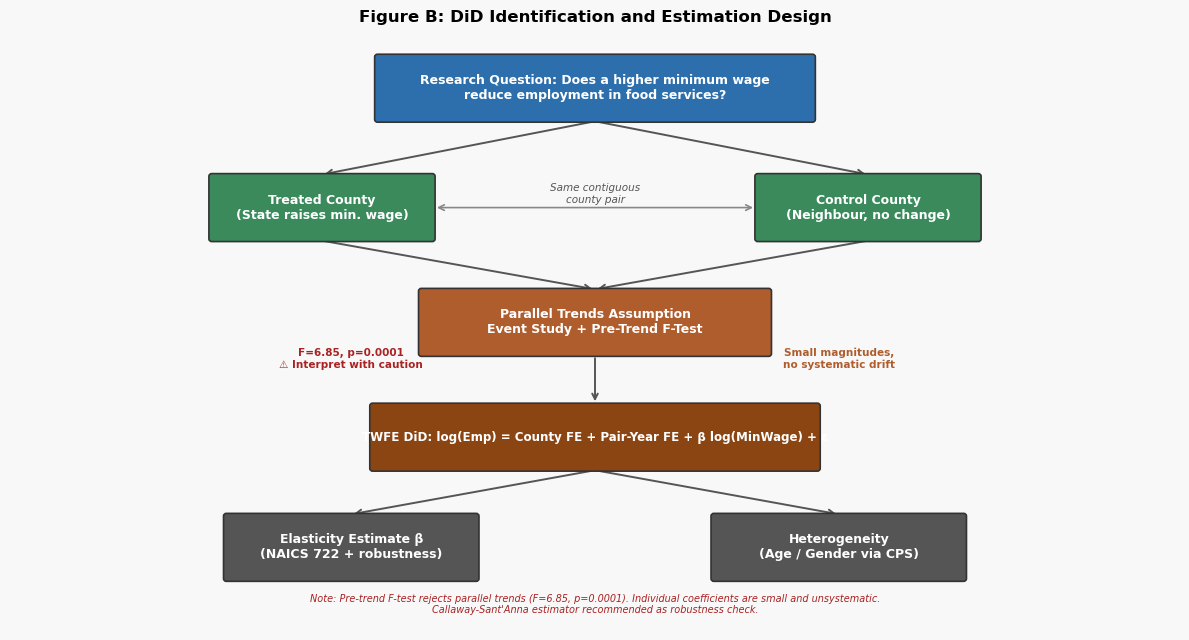

Saved fig_flowchart_did.png


In [3]:
fig2, ax2 = plt.subplots(figsize=(12, 6.5))
ax2.set_xlim(0, 12)
ax2.set_ylim(0, 6.5)
ax2.axis("off")
fig2.patch.set_facecolor("#F8F8F8")

C1 = "#2C6FAC"
C2 = "#3A8A5C"
C3 = "#8B4513"
C4 = "#B05D2E"
C5 = "#555555"
C_WARN = "#AA2222"

BW2, BH2 = 2.3, 0.72

draw_box(
    ax2,
    6.0,
    5.9,
    4.5,
    BH2,
    "Research Question: Does a higher minimum wage\nreduce employment in food services?",
    C1,
    fontsize=9,
)

draw_box(ax2, 3.2, 4.6, BW2, BH2, "Treated County\n(State raises min. wage)", C2)
draw_box(ax2, 8.8, 4.6, BW2, BH2, "Control County\n(Neighbour, no change)", C2)

arrow(ax2, 6.0, 5.9 - BH2 / 2, 3.2, 4.6 + BH2 / 2)
arrow(ax2, 6.0, 5.9 - BH2 / 2, 8.8, 4.6 + BH2 / 2)

ax2.annotate(
    "",
    xy=(8.8 - BW2 / 2, 4.6),
    xytext=(3.2 + BW2 / 2, 4.6),
    arrowprops=dict(arrowstyle="<->", color="#888", lw=1.2),
)
ax2.text(
    6.0,
    4.75,
    "Same contiguous\ncounty pair",
    ha="center",
    va="center",
    fontsize=7.5,
    color="#555",
    style="italic",
)

draw_box(
    ax2,
    6.0,
    3.35,
    3.6,
    BH2,
    "Parallel Trends Assumption\nEvent Study + Pre-Trend F-Test",
    C4,
)
arrow(ax2, 3.2, 4.6 - BH2 / 2, 6.0, 3.35 + BH2 / 2)
arrow(ax2, 8.8, 4.6 - BH2 / 2, 6.0, 3.35 + BH2 / 2)

ax2.text(
    3.5,
    2.85,
    "F=6.85, p=0.0001\n⚠ Interpret with caution",
    ha="center",
    fontsize=7.5,
    color=C_WARN,
    fontweight="bold",
)
ax2.text(
    8.5,
    2.85,
    "Small magnitudes,\nno systematic drift",
    ha="center",
    fontsize=7.5,
    color="#B05D2E",
    fontweight="bold",
)

draw_box(
    ax2,
    6.0,
    2.1,
    4.6,
    BH2,
    "TWFE DiD: log(Emp) = County FE + Pair-Year FE + β log(MinWage) + ε",
    C3,
    fontsize=8.5,
)
arrow(ax2, 6.0, 3.35 - BH2 / 2, 6.0, 2.1 + BH2 / 2)

draw_box(ax2, 3.5, 0.9, 2.6, BH2, "Elasticity Estimate β\n(NAICS 722 + robustness)", C5)
draw_box(ax2, 8.5, 0.9, 2.6, BH2, "Heterogeneity\n(Age / Gender via CPS)", C5)

arrow(ax2, 6.0, 2.1 - BH2 / 2, 3.5, 0.9 + BH2 / 2)
arrow(ax2, 6.0, 2.1 - BH2 / 2, 8.5, 0.9 + BH2 / 2)

ax2.text(
    6.0,
    0.18,
    "Note: Pre-trend F-test rejects parallel trends (F=6.85, p=0.0001). "
    "Individual coefficients are small and unsystematic.\n"
    "Callaway-Sant'Anna estimator recommended as robustness check.",
    ha="center",
    fontsize=7,
    color=C_WARN,
    style="italic",
)

ax2.set_title(
    "Figure B: DiD Identification and Estimation Design",
    fontsize=12,
    fontweight="bold",
    pad=8,
)

plt.tight_layout()
plt.savefig(FIGURES / "fig_flowchart_did.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved fig_flowchart_did.png")